<a href="https://colab.research.google.com/github/dharathi/Hyd-Diesel-Engine-Project/blob/main/Python%20notebooks/NN_VED_OBD2_Leakage_Controlled_Sensitivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NN VED-OBD2 Ablation Study

This notebook runs the ablation study for the union multi-domain neural network used for cross-domain vehicle-energy prediction.

It compares four variants:

1. **Full model**: union features + feature-availability mask + domain-specific encoders
2. **Ablation A**: union features + **no** feature-availability mask + domain-specific encoders
3. **Ablation B**: union features + feature-availability mask + **shared encoder only**
4. **Ablation C**: union features + **no** feature-availability mask + **shared encoder only**

This version is split into separate execution cells so each variant can be run one at a time in Google Colab.

## Colab runtime notes

- A **GPU runtime is recommended** for this notebook. It should train noticeably faster than CPU for these four runs.
- In Colab, go to **Runtime -> Change runtime type -> T4 GPU** (or another available GPU) before running.
- If you already ran part of the notebook once, you do **not** need to clear the output folder unless you want a completely clean ablation-results directory.
- The notebook saves each variant result separately, so partial progress is fine.

## What this ablation is testing

The proposed union model contains two design choices that are important to test:

- **Feature-availability mask**: tells the network which inputs were actually observed and which were only filled during imputation.
- **Domain-specific encoders**: let VED and OBD2 observations enter the shared latent space through separate domain-aware branches.

By removing these components one at a time, we can check whether the final performance gain comes from:

- the larger union feature space alone,
- the feature-availability mask,
- the domain-specific encoders,
- or the combination of both.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import copy
import glob
import json
import math
import os
import random
import re
import shutil
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception:
    pass

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU name:', torch.cuda.get_device_name(0))

VED_GLOB = '/content/drive/MyDrive/Data/VED-dataset/VED_HEV_PHEV/*.csv'
OBD2_GLOB = '/content/drive/MyDrive/Data/OBD2-datalogger/Fiesta-TD-Ci/*.csv'

OUTPUT_DIR = '/content/drive/MyDrive/Data/VED-dataset/leakage_controlled_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

EPOCHS = 20
BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
FUEL_LOSS_WEIGHT = 1.0
SOC_LOSS_WEIGHT = 0.4
DOMAIN_VED = 0
DOMAIN_OBD2 = 1

LEAKAGE_CONTROLLED = True
LEAKAGE_SENSITIVE_OBD2_FEATURES = {
    'instant_fuel_economy_mpg',
    'total_fuel_economy_mpg',
    'instant_co2_rate_lb_per_mile',
}


Mounted at /content/drive
Using device: cuda
GPU name: Tesla T4


## Optional cleanup

Run the next cell only if you want to delete old ablation-study outputs before starting again.
If you want to keep previous CSVs and model files, skip it.

In [2]:
CLEAR_OUTPUT_DIR = True

if CLEAR_OUTPUT_DIR:
    for item in os.listdir(OUTPUT_DIR):
        item_path = os.path.join(OUTPUT_DIR, item)
        if os.path.isdir(item_path):
            shutil.rmtree(item_path)
        else:
            os.remove(item_path)
    print('Cleared:', OUTPUT_DIR)
else:
    print('Skipping cleanup. Existing output files are preserved.')

Cleared: /content/drive/MyDrive/Data/VED-dataset/leakage_controlled_outputs


In [3]:
def normalize_name(name):
    name = str(name).strip().lower()
    name = name.replace('[', ' ').replace(']', ' ')
    name = name.replace('(', ' ').replace(')', ' ')
    name = name.replace('%', ' percent ')
    name = name.replace('/', ' ')
    name = re.sub(r'[^a-z0-9]+', '_', name)
    return re.sub(r'_+', '_', name).strip('_')

def resolve_alias(columns, aliases):
    normalized = {normalize_name(col): col for col in columns}
    for alias in aliases:
        found = normalized.get(normalize_name(alias))
        if found is not None:
            return found
    return None

def identity(series):
    return pd.to_numeric(series, errors='coerce')

def fahrenheit_to_celsius(series):
    values = pd.to_numeric(series, errors='coerce')
    return (values - 32.0) * (5.0 / 9.0)

def mph_to_kmh(series):
    values = pd.to_numeric(series, errors='coerce')
    return values * 1.60934

def inhg_to_kpa(series):
    values = pd.to_numeric(series, errors='coerce')
    return values * 3.38639

def gal_per_hr_to_l_per_hr(series):
    values = pd.to_numeric(series, errors='coerce')
    return values * 3.78541

UNION_FEATURE_SPECS = [
    {'name': 'day_num', 'ved_aliases': ['DayNum', 'Day Num'], 'obd2_aliases': [], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'veh_id', 'ved_aliases': ['VehId', 'Veh ID'], 'obd2_aliases': [], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'trip_id', 'ved_aliases': ['Trip'], 'obd2_aliases': [], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'time_signal', 'ved_aliases': ['Timestamp(ms)', 'Timestamp (ms)', 'Timestamp [ms]'], 'obd2_aliases': ['Time (sec)', 'Time [sec]', 'Time'], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'latitude_deg', 'ved_aliases': ['Latitude[deg]', 'Latitude (deg)', 'Latitude'], 'obd2_aliases': ['Latitude (deg)', 'Latitude'], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'longitude_deg', 'ved_aliases': ['Longitude[deg]', 'Longitude (deg)', 'Longitude'], 'obd2_aliases': ['Longitude (deg)', 'Longitude'], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'vehicle_speed_kmh', 'ved_aliases': ['Vehicle Speed[km/h]', 'Vehicle speed[km/h]', 'Speed[km/h]'], 'obd2_aliases': ['Vehicle speed (MPH)', 'Vehicle speed (km/h)', 'Vehicle speed'], 'ved_transform': identity, 'obd2_transform': mph_to_kmh},
    {'name': 'engine_rpm', 'ved_aliases': ['Engine RPM[RPM]', 'Engine RPM', 'RPM'], 'obd2_aliases': ['Engine RPM (RPM)', 'Engine RPM', 'RPM'], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'outside_air_temp_c', 'ved_aliases': ['OAT[DegC]', 'OAT (DegC)', 'Outside Air Temperature[C]', 'Ambient Temperature[C]'], 'obd2_aliases': ['Ambient air temperature (degF)', 'Ambient air temperature (degC)', 'Ambient air temperature'], 'ved_transform': identity, 'obd2_transform': fahrenheit_to_celsius},
    {'name': 'air_conditioning_power_kw', 'ved_aliases': ['Air Conditioning Power[kW]', 'Air Conditioning Power (kW)'], 'obd2_aliases': [], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'heater_power_watts', 'ved_aliases': ['Heater Power[Watts]', 'Heater Power (Watts)'], 'obd2_aliases': [], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'hv_battery_current_a', 'ved_aliases': ['HV Battery Current[A]', 'HV Battery Current (A)'], 'obd2_aliases': [], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'hv_battery_voltage_v', 'ved_aliases': ['HV Battery Voltage[V]', 'HV Battery Voltage (V)'], 'obd2_aliases': [], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'load_percent', 'ved_aliases': ['Calculated load value[%]', 'Calculated load value (%)', 'Engine Load[%]', 'Load[%]'], 'obd2_aliases': ['Calculated load value (%)', 'Calculated load value [%]', 'Engine load (%)'], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'coolant_temp_c', 'ved_aliases': ['Engine Coolant Temp[C]', 'Engine Coolant Temperature[C]', 'Coolant Temperature[C]'], 'obd2_aliases': ['Engine coolant temperature (°F)', 'Engine coolant temperature (degF)', 'Engine coolant temperature'], 'ved_transform': identity, 'obd2_transform': fahrenheit_to_celsius},
    {'name': 'manifold_pressure_kpa', 'ved_aliases': ['Intake Manifold Absolute Pressure[kPa]', 'Manifold Absolute Pressure[kPa]', 'MAP[kPa]'], 'obd2_aliases': ['Intake manifold absolute pressure (inHg)', 'Intake manifold absolute pressure (kPa)', 'MAP (kPa)'], 'ved_transform': identity, 'obd2_transform': inhg_to_kpa},
    {'name': 'instant_fuel_economy_mpg', 'ved_aliases': [], 'obd2_aliases': ['Instant Fuel Economy (MPG)'], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'total_fuel_economy_mpg', 'ved_aliases': [], 'obd2_aliases': ['Total Fuel Economy (MPG)'], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'instant_co2_rate_lb_per_mile', 'ved_aliases': [], 'obd2_aliases': ['Instant CO2 rate (lb/mile)'], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'trip_distance_miles', 'ved_aliases': [], 'obd2_aliases': ['Trip Distance (miles)'], 'ved_transform': identity, 'obd2_transform': identity},
    {'name': 'trip_duration_min', 'ved_aliases': [], 'obd2_aliases': ['Trip Duration (min)'], 'ved_transform': identity, 'obd2_transform': identity},
]

if LEAKAGE_CONTROLLED:
    UNION_FEATURE_SPECS = [
        spec for spec in UNION_FEATURE_SPECS
        if spec['name'] not in LEAKAGE_SENSITIVE_OBD2_FEATURES
    ]

VED_FUEL_ALIASES = ['Fuel Rate[L/hr]', 'Fuel Rate [L/hr]', 'Fuel Rate (L/hr)']
VED_SOC_ALIASES = ['HV Battery SOC[%]', 'HV Battery SOC [%]', 'HV Battery SOC (%)']
OBD2_FUEL_ALIASES = ['Fuel Rate (gal/hr)', 'Fuel Rate [gal/hr]']

def read_obd2_files(obd2_glob):
    files = sorted(glob.glob(obd2_glob))
    if not files:
        raise FileNotFoundError(f'No OBD2 CSV files found for {obd2_glob}')
    frames = []
    for file in files:
        frame = pd.read_csv(file, skiprows=1, encoding='utf-8-sig', skipinitialspace=True, on_bad_lines='skip')
        frame['source_file'] = Path(file).name
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

def get_ved_files(ved_glob):
    files = sorted(glob.glob(ved_glob))
    if not files:
        raise FileNotFoundError(f'No VED CSV files found for {ved_glob}')
    return files

def resolve_union_specs(ved_columns, obd2_columns):
    resolved = []
    for spec in UNION_FEATURE_SPECS:
        item = dict(spec)
        item['ved_col'] = resolve_alias(ved_columns, spec['ved_aliases']) if spec['ved_aliases'] else None
        item['obd2_col'] = resolve_alias(obd2_columns, spec['obd2_aliases']) if spec['obd2_aliases'] else None
        if item['ved_col'] is not None or item['obd2_col'] is not None:
            resolved.append(item)
    return resolved

def build_ved_frame(files, specs, fuel_col, soc_col):
    required_cols = {fuel_col, soc_col}
    required_cols.update(item['ved_col'] for item in specs if item['ved_col'] is not None)
    frames = []
    for idx, file in enumerate(files, start=1):
        try:
            frame = pd.read_csv(file, usecols=lambda c: c in required_cols)
            if not frame.empty:
                frames.append(frame)
            if idx % 25 == 0:
                print(f'Loaded {idx} VED files...')
        except Exception as exc:
            print(f'Skipping {file} because of {type(exc).__name__}: {exc}')
    if not frames:
        raise ValueError('No VED frames were loaded.')
    raw = pd.concat(frames, ignore_index=True)
    out = pd.DataFrame(index=raw.index)
    mask = pd.DataFrame(index=raw.index)
    for item in specs:
        if item['ved_col'] is not None:
            values = item['ved_transform'](raw[item['ved_col']])
            out[item['name']] = values
            mask[item['name']] = values.notna().astype(float)
        else:
            out[item['name']] = np.nan
            mask[item['name']] = 0.0
    out['fuel_rate_lph'] = pd.to_numeric(raw[fuel_col], errors='coerce')
    out['soc_percent'] = pd.to_numeric(raw[soc_col], errors='coerce')
    out['dataset_name'] = 'VED'
    out['domain_id'] = DOMAIN_VED
    return out, mask

def build_obd2_frame(obd2_df, specs, fuel_col):
    out = pd.DataFrame(index=obd2_df.index)
    mask = pd.DataFrame(index=obd2_df.index)
    for item in specs:
        if item['obd2_col'] is not None:
            values = item['obd2_transform'](obd2_df[item['obd2_col']])
            out[item['name']] = values
            mask[item['name']] = values.notna().astype(float)
        else:
            out[item['name']] = np.nan
            mask[item['name']] = 0.0
    out['fuel_rate_lph'] = gal_per_hr_to_l_per_hr(obd2_df[fuel_col])
    out['soc_percent'] = np.nan
    out['dataset_name'] = 'OBD2'
    out['domain_id'] = DOMAIN_OBD2
    out['source_file'] = obd2_df['source_file']
    return out, mask

def chron_split(df, mask_df, train_ratio=0.8, val_ratio=0.1):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return (
        df.iloc[:train_end].reset_index(drop=True), mask_df.iloc[:train_end].reset_index(drop=True),
        df.iloc[train_end:val_end].reset_index(drop=True), mask_df.iloc[train_end:val_end].reset_index(drop=True),
        df.iloc[val_end:].reset_index(drop=True), mask_df.iloc[val_end:].reset_index(drop=True),
    )

def split_obd2_by_trip(df, mask_df):
    trips = sorted(df['source_file'].dropna().unique().tolist())
    if len(trips) < 2:
        raise ValueError('Need at least two OBD2 trip files for split.')
    test_trip = trips[-1]
    train_idx = df.index[df['source_file'] != test_trip]
    test_idx = df.index[df['source_file'] == test_trip]
    train_pool = df.loc[train_idx].reset_index(drop=True)
    train_pool_mask = mask_df.loc[train_idx].reset_index(drop=True)
    test_df = df.loc[test_idx].reset_index(drop=True)
    test_mask = mask_df.loc[test_idx].reset_index(drop=True)
    cut = int(len(train_pool) * 0.8)
    return (
        train_pool.iloc[:cut].reset_index(drop=True), train_pool_mask.iloc[:cut].reset_index(drop=True),
        train_pool.iloc[cut:].reset_index(drop=True), train_pool_mask.iloc[cut:].reset_index(drop=True),
        test_df.reset_index(drop=True), test_mask.reset_index(drop=True),
        test_trip,
    )

class UnionDataset(Dataset):
    def __init__(self, features, avail_mask, domains, targets, target_mask):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.avail_mask = torch.tensor(avail_mask, dtype=torch.float32)
        self.domains = torch.tensor(domains, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.target_mask = torch.tensor(target_mask, dtype=torch.float32)
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        return self.features[idx], self.avail_mask[idx], self.domains[idx], self.targets[idx], self.target_mask[idx]

def masked_mse(pred, target, target_mask):
    diff2 = (pred - target) ** 2
    weighted = diff2 * target_mask
    denom = target_mask.sum(dim=0).clamp_min(1.0)
    return weighted.sum(dim=0) / denom

def make_arrays(df, feature_cols, avail_mask_df):
    X = df[feature_cols].to_numpy(dtype=float)
    avail = avail_mask_df[feature_cols].to_numpy(dtype=float)
    domains = df['domain_id'].to_numpy(dtype=int)
    y = np.column_stack([
        df['fuel_rate_lph'].to_numpy(dtype=float),
        df['soc_percent'].to_numpy(dtype=float),
    ])
    target_mask = np.column_stack([
        np.isfinite(df['fuel_rate_lph'].to_numpy(dtype=float)).astype(float),
        np.isfinite(df['soc_percent'].to_numpy(dtype=float)).astype(float),
    ])
    return X, avail, domains, y, target_mask

## Resolve the union feature space

This section identifies the shared, VED-only, and OBD2-only features. The ablation study reuses this same union feature space for every model variant.

In [4]:
ved_files = get_ved_files(VED_GLOB)
ved_preview = pd.read_csv(ved_files[0], nrows=5)
ved_columns = list(ved_preview.columns)

obd2_raw = read_obd2_files(OBD2_GLOB)
obd2_columns = list(obd2_raw.columns)

resolved_specs = resolve_union_specs(ved_columns, obd2_columns)
feature_cols = [item['name'] for item in resolved_specs]

ved_only = [item['name'] for item in resolved_specs if item['ved_col'] is not None and item['obd2_col'] is None]
obd2_only = [item['name'] for item in resolved_specs if item['ved_col'] is None and item['obd2_col'] is not None]
shared = [item['name'] for item in resolved_specs if item['ved_col'] is not None and item['obd2_col'] is not None]

ved_fuel_col = resolve_alias(ved_columns, VED_FUEL_ALIASES)
ved_soc_col = resolve_alias(ved_columns, VED_SOC_ALIASES)
obd2_fuel_col = resolve_alias(obd2_columns, OBD2_FUEL_ALIASES)

if ved_fuel_col is None or ved_soc_col is None:
    raise ValueError('Could not resolve VED targets.')
if obd2_fuel_col is None:
    raise ValueError('Could not resolve OBD2 fuel target.')

print('Leakage-controlled mode:', LEAKAGE_CONTROLLED)
print('Excluded leakage-sensitive OBD2 features:', sorted(LEAKAGE_SENSITIVE_OBD2_FEATURES))
print('Total union features resolved:', len(feature_cols))
print('Shared features:', shared)
print('VED-only features:', ved_only)
print('OBD2-only features:', obd2_only)
if LEAKAGE_CONTROLLED:
    assert not set(feature_cols).intersection(LEAKAGE_SENSITIVE_OBD2_FEATURES), 'Leakage-sensitive features remain in the union set.'
    assert len(feature_cols) == 18, f'Expected 18 leakage-controlled union features, found {len(feature_cols)}.'


Leakage-controlled mode: True
Excluded leakage-sensitive OBD2 features: ['instant_co2_rate_lb_per_mile', 'instant_fuel_economy_mpg', 'total_fuel_economy_mpg']
Total union features resolved: 18
Shared features: ['time_signal', 'latitude_deg', 'longitude_deg', 'vehicle_speed_kmh']
VED-only features: ['day_num', 'veh_id', 'trip_id', 'engine_rpm', 'outside_air_temp_c', 'air_conditioning_power_kw', 'heater_power_watts', 'hv_battery_current_a', 'hv_battery_voltage_v']
OBD2-only features: ['load_percent', 'coolant_temp_c', 'manifold_pressure_kpa', 'trip_distance_miles', 'trip_duration_min']


## Build dataset frames, split the data, and preprocess once

All four model variants use the same cleaned rows, imputers, scalers, and splits. This keeps the comparison fair.

In [5]:
ved_df, ved_avail = build_ved_frame(ved_files, resolved_specs, ved_fuel_col, ved_soc_col)
obd2_df, obd2_avail = build_obd2_frame(obd2_raw, resolved_specs, obd2_fuel_col)

ved_keep = ved_df['fuel_rate_lph'].notna() & ved_df['soc_percent'].notna()
ved_df = ved_df.loc[ved_keep].reset_index(drop=True)
ved_avail = ved_avail.loc[ved_keep].reset_index(drop=True)

obd2_keep = obd2_df['fuel_rate_lph'].notna()
obd2_df = obd2_df.loc[obd2_keep].reset_index(drop=True)
obd2_avail = obd2_avail.loc[obd2_keep].reset_index(drop=True)

print('VED rows:', len(ved_df))
print('OBD2 rows:', len(obd2_df))

ved_train_df, ved_train_avail, ved_val_df, ved_val_avail, ved_test_df, ved_test_avail = chron_split(ved_df, ved_avail)
obd2_train_df, obd2_train_avail, obd2_val_df, obd2_val_avail, obd2_test_df, obd2_test_avail, held_out_trip = split_obd2_by_trip(obd2_df, obd2_avail)

print('VED split sizes:', len(ved_train_df), len(ved_val_df), len(ved_test_df))
print('OBD2 split sizes:', len(obd2_train_df), len(obd2_val_df), len(obd2_test_df))
print('Held-out OBD2 trip:', held_out_trip)

X_ved_train, A_ved_train, D_ved_train, y_ved_train, tm_ved_train = make_arrays(ved_train_df, feature_cols, ved_train_avail)
X_ved_val, A_ved_val, D_ved_val, y_ved_val, tm_ved_val = make_arrays(ved_val_df, feature_cols, ved_val_avail)
X_ved_test, A_ved_test, D_ved_test, y_ved_test, tm_ved_test = make_arrays(ved_test_df, feature_cols, ved_test_avail)

X_obd2_train, A_obd2_train, D_obd2_train, y_obd2_train, tm_obd2_train = make_arrays(obd2_train_df, feature_cols, obd2_train_avail)
X_obd2_val, A_obd2_val, D_obd2_val, y_obd2_val, tm_obd2_val = make_arrays(obd2_val_df, feature_cols, obd2_val_avail)
X_obd2_test, A_obd2_test, D_obd2_test, y_obd2_test, tm_obd2_test = make_arrays(obd2_test_df, feature_cols, obd2_test_avail)

imputer = SimpleImputer(strategy='constant', fill_value=0.0, keep_empty_features=True)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_ved_train_imp = imputer.fit_transform(X_ved_train)
X_ved_val_imp = imputer.transform(X_ved_val)
X_ved_test_imp = imputer.transform(X_ved_test)
X_obd2_train_imp = imputer.transform(X_obd2_train)
X_obd2_val_imp = imputer.transform(X_obd2_val)
X_obd2_test_imp = imputer.transform(X_obd2_test)

X_ved_train_scaled = scaler_X.fit_transform(X_ved_train_imp)
X_ved_val_scaled = scaler_X.transform(X_ved_val_imp)
X_ved_test_scaled = scaler_X.transform(X_ved_test_imp)
X_obd2_train_scaled = scaler_X.transform(X_obd2_train_imp)
X_obd2_val_scaled = scaler_X.transform(X_obd2_val_imp)
X_obd2_test_scaled = scaler_X.transform(X_obd2_test_imp)

y_ved_train_scaled = scaler_y.fit_transform(y_ved_train)
y_ved_val_scaled = scaler_y.transform(y_ved_val)
y_ved_test_scaled = scaler_y.transform(y_ved_test)

y_obd2_train_fill = y_obd2_train.copy()
y_obd2_val_fill = y_obd2_val.copy()
y_obd2_test_fill = y_obd2_test.copy()
soc_fill = float(np.nanmean(y_ved_train[:, 1]))
y_obd2_train_fill[:, 1] = soc_fill
y_obd2_val_fill[:, 1] = soc_fill
y_obd2_test_fill[:, 1] = soc_fill

y_obd2_train_scaled = scaler_y.transform(y_obd2_train_fill)
y_obd2_val_scaled = scaler_y.transform(y_obd2_val_fill)
y_obd2_test_scaled = scaler_y.transform(y_obd2_test_fill)

X_train = np.vstack([X_ved_train_scaled, X_obd2_train_scaled])
A_train = np.vstack([A_ved_train, A_obd2_train])
D_train = np.concatenate([D_ved_train, D_obd2_train])
y_train = np.vstack([y_ved_train_scaled, y_obd2_train_scaled])
tm_train = np.vstack([tm_ved_train, tm_obd2_train])

X_val = np.vstack([X_ved_val_scaled, X_obd2_val_scaled])
A_val = np.vstack([A_ved_val, A_obd2_val])
D_val = np.concatenate([D_ved_val, D_obd2_val])
y_val = np.vstack([y_ved_val_scaled, y_obd2_val_scaled])
tm_val = np.vstack([tm_ved_val, tm_obd2_val])

results_rows = []
history_by_variant = {}
predictions_by_variant = {}

print('Preprocessing complete.')

Loaded 25 VED files...
Loaded 50 VED files...
VED rows: 894275
OBD2 rows: 3624
VED split sizes: 715420 89427 89428
OBD2 split sizes: 2275 569 780
Held-out OBD2 trip: CSVLog_20260312_183748.csv
Preprocessing complete.


## Define the model variants and helper functions

The next cell defines the full union model structure, the ablation toggles, and the functions used to train and evaluate each variant separately.

In [6]:
class AblationUnionNet(nn.Module):
    def __init__(self, input_dim, use_mask=True, use_domain_specific_encoders=True):
        super().__init__()
        self.use_mask = use_mask
        self.use_domain_specific_encoders = use_domain_specific_encoders
        encoder_input_dim = input_dim * 2 if use_mask else input_dim

        def make_encoder():
            return nn.Sequential(
                nn.Linear(encoder_input_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 32),
                nn.ReLU(),
            )

        if use_domain_specific_encoders:
            self.ved_encoder = make_encoder()
            self.obd2_encoder = make_encoder()
            self.shared_encoder = None
        else:
            self.shared_encoder = make_encoder()
            self.ved_encoder = None
            self.obd2_encoder = None

        self.shared = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.fuel_head = nn.Linear(16, 1)
        self.soc_head = nn.Linear(16, 1)

    def forward(self, x, avail_mask, domains):
        if self.use_mask:
            x_masked = x * avail_mask
            encoder_input = torch.cat([x_masked, avail_mask], dim=1)
        else:
            encoder_input = x

        if self.use_domain_specific_encoders:
            ved_latent = self.ved_encoder(encoder_input)
            obd2_latent = self.obd2_encoder(encoder_input)
            domain_selector = (domains == DOMAIN_OBD2).float().unsqueeze(1)
            latent = ved_latent * (1.0 - domain_selector) + obd2_latent * domain_selector
        else:
            latent = self.shared_encoder(encoder_input)

        shared = self.shared(latent)
        fuel = self.fuel_head(shared)
        soc = self.soc_head(shared)
        return torch.cat([fuel, soc], dim=1)

def fit_model(model, train_loader, val_tensors, optimizer, epochs):
    best_state = None
    best_val = float('inf')
    history = {'train_total': [], 'val_total': [], 'train_fuel': [], 'train_soc': [], 'val_fuel': [], 'val_soc': []}
    vx, vm, vd, vy, vt = [t.to(device) for t in val_tensors]

    for epoch in range(epochs):
        model.train()
        running_total = 0.0
        running_fuel = 0.0
        running_soc = 0.0
        seen = 0

        for bx, bm, bd, by, bt in train_loader:
            bx = bx.to(device)
            bm = bm.to(device)
            bd = bd.to(device)
            by = by.to(device)
            bt = bt.to(device)

            optimizer.zero_grad()
            pred = model(bx, bm, bd)
            losses = masked_mse(pred, by, bt)
            total = FUEL_LOSS_WEIGHT * losses[0] + SOC_LOSS_WEIGHT * losses[1]
            total.backward()
            optimizer.step()

            batch_size = len(bx)
            running_total += total.item() * batch_size
            running_fuel += losses[0].item() * batch_size
            running_soc += losses[1].item() * batch_size
            seen += batch_size

        model.eval()
        with torch.no_grad():
            vpred = model(vx, vm, vd)
            vlosses = masked_mse(vpred, vy, vt)
            vtotal = FUEL_LOSS_WEIGHT * vlosses[0] + SOC_LOSS_WEIGHT * vlosses[1]

        train_total = running_total / max(seen, 1)
        train_fuel = running_fuel / max(seen, 1)
        train_soc = running_soc / max(seen, 1)

        history['train_total'].append(train_total)
        history['val_total'].append(vtotal.item())
        history['train_fuel'].append(train_fuel)
        history['train_soc'].append(train_soc)
        history['val_fuel'].append(vlosses[0].item())
        history['val_soc'].append(vlosses[1].item())

        if vtotal.item() < best_val:
            best_val = vtotal.item()
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch + 1}/{epochs} | train_total={train_total:.4f} train_fuel={train_fuel:.4f} train_soc={train_soc:.4f} | "
            f"val_total={vtotal.item():.4f} val_fuel={vlosses[0].item():.4f} val_soc={vlosses[1].item():.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)
    return history

def compute_metrics(y_true, y_pred, target_mask):
    targets = ['fuel_rate_lph', 'soc_percent']
    metrics = {}
    for idx, name in enumerate(targets):
        valid = target_mask[:, idx] > 0
        if valid.sum() == 0:
            metrics[name] = {'mse': np.nan, 'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'count': 0}
            continue
        actual = y_true[valid, idx]
        pred = y_pred[valid, idx]
        mse = mean_squared_error(actual, pred)
        metrics[name] = {
            'mse': mse,
            'rmse': math.sqrt(mse),
            'mae': mean_absolute_error(actual, pred),
            'r2': r2_score(actual, pred),
            'count': int(valid.sum()),
        }
    return metrics

def predict_model(model, x, a, d):
    xt = torch.tensor(x, dtype=torch.float32).to(device)
    at = torch.tensor(a, dtype=torch.float32).to(device)
    dt = torch.tensor(d, dtype=torch.long).to(device)
    with torch.no_grad():
        pred_scaled = model(xt, at, dt).cpu().numpy()
    return scaler_y.inverse_transform(pred_scaled)

def print_metric_block(label, metrics):
    for target_name, target_metrics in metrics.items():
        if target_metrics['count'] == 0:
            print(f'{label} | {target_name}: no valid targets')
            continue
        print(
            f"{label} | {target_name}: "
            f"MSE={target_metrics['mse']:.4f} RMSE={target_metrics['rmse']:.4f} "
            f"MAE={target_metrics['mae']:.4f} R2={target_metrics['r2']:.4f}"
        )

def run_variant(variant_name, paper_label, use_mask, use_domain_specific_encoders):
    global results_rows, history_by_variant, predictions_by_variant

    print('\n' + '=' * 100)
    print('Running:', variant_name)
    print(paper_label)
    print('=' * 100)

    train_loader = DataLoader(
        UnionDataset(X_train, A_train, D_train, y_train, tm_train),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    val_tensors = (
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(A_val, dtype=torch.float32),
        torch.tensor(D_val, dtype=torch.long),
        torch.tensor(y_val, dtype=torch.float32),
        torch.tensor(tm_val, dtype=torch.float32),
    )

    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = AblationUnionNet(
        input_dim=len(feature_cols),
        use_mask=use_mask,
        use_domain_specific_encoders=use_domain_specific_encoders,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = fit_model(model, train_loader, val_tensors, optimizer, EPOCHS)

    ved_pred = predict_model(model, X_ved_test_scaled, A_ved_test, D_ved_test)
    obd2_pred = predict_model(model, X_obd2_test_scaled, A_obd2_test, D_obd2_test)

    ved_metrics = compute_metrics(y_ved_test, ved_pred, tm_ved_test)
    obd2_metrics = compute_metrics(y_obd2_test, obd2_pred, tm_obd2_test)

    print_metric_block('VED test', ved_metrics)
    print_metric_block('OBD2 test', obd2_metrics)

    results_rows = [row for row in results_rows if row['variant_name'] != variant_name]
    results_rows.append({
        'variant_name': variant_name,
        'paper_label': paper_label,
        'uses_mask': use_mask,
        'uses_domain_specific_encoders': use_domain_specific_encoders,
        'ved_fuel_rmse': ved_metrics['fuel_rate_lph']['rmse'],
        'ved_fuel_mae': ved_metrics['fuel_rate_lph']['mae'],
        'ved_fuel_r2': ved_metrics['fuel_rate_lph']['r2'],
        'ved_soc_rmse': ved_metrics['soc_percent']['rmse'],
        'ved_soc_mae': ved_metrics['soc_percent']['mae'],
        'ved_soc_r2': ved_metrics['soc_percent']['r2'],
        'obd2_fuel_rmse': obd2_metrics['fuel_rate_lph']['rmse'],
        'obd2_fuel_mae': obd2_metrics['fuel_rate_lph']['mae'],
        'obd2_fuel_r2': obd2_metrics['fuel_rate_lph']['r2'],
    })

    history_by_variant[variant_name] = history
    predictions_by_variant[variant_name] = {
        'ved_pred': ved_pred,
        'obd2_pred': obd2_pred,
    }

    variant_dir = os.path.join(OUTPUT_DIR, normalize_name(variant_name))
    os.makedirs(variant_dir, exist_ok=True)
    pd.DataFrame([row for row in results_rows if row['variant_name'] == variant_name]).to_csv(
        os.path.join(variant_dir, 'metrics.csv'), index=False
    )
    np.save(os.path.join(variant_dir, 'obd2_fuel_predictions.npy'), obd2_pred[:, 0])
    np.save(os.path.join(variant_dir, 'ved_soc_predictions.npy'), ved_pred[:, 1])
    torch.save(model.state_dict(), os.path.join(variant_dir, 'model_state_dict.pth'))

    results_df = pd.DataFrame(results_rows).sort_values('variant_name').reset_index(drop=True)
    display(results_df)
    return model, history, ved_pred, obd2_pred, results_df

## Run the full model

Run this cell first. After that, run the ablation cells one by one.

In [7]:
full_model_outputs = run_variant(
    variant_name='Full model',
    paper_label='Union features + mask + domain-specific encoders',
    use_mask=True,
    use_domain_specific_encoders=True,
)


Running: Full model
Union features + mask + domain-specific encoders
Epoch 1/20 | train_total=0.2435 train_fuel=0.1660 train_soc=0.1938 | val_total=0.0772 val_fuel=0.0515 val_soc=0.0642
Epoch 2/20 | train_total=0.1285 train_fuel=0.1030 train_soc=0.0639 | val_total=0.0815 val_fuel=0.0501 val_soc=0.0785
Epoch 3/20 | train_total=0.1237 train_fuel=0.1007 train_soc=0.0575 | val_total=0.0793 val_fuel=0.0488 val_soc=0.0764
Epoch 4/20 | train_total=0.1205 train_fuel=0.0986 train_soc=0.0549 | val_total=0.0872 val_fuel=0.0514 val_soc=0.0895
Epoch 5/20 | train_total=0.1185 train_fuel=0.0972 train_soc=0.0531 | val_total=0.0887 val_fuel=0.0515 val_soc=0.0928
Epoch 6/20 | train_total=0.1170 train_fuel=0.0962 train_soc=0.0520 | val_total=0.0868 val_fuel=0.0496 val_soc=0.0931
Epoch 7/20 | train_total=0.1155 train_fuel=0.0951 train_soc=0.0512 | val_total=0.0893 val_fuel=0.0507 val_soc=0.0966
Epoch 8/20 | train_total=0.1141 train_fuel=0.0940 train_soc=0.0502 | val_total=0.0835 val_fuel=0.0476 val_soc=0

,variant_name,paper_label,uses_mask,uses_domain_specific_encoders,ved_fuel_rmse,ved_fuel_mae,ved_fuel_r2,ved_soc_rmse,ved_soc_mae,ved_soc_r2,obd2_fuel_rmse,obd2_fuel_mae,obd2_fuel_r2
0,Full model,Union features + mask + domain-specific encoders,True,True,0.714444,0.24211,0.861179,10.227867,7.608688,0.888313,0.965536,0.732115,-0.062234


## Run Ablation A

This removes the feature-availability mask but keeps the domain-specific encoders.

In [8]:
ablation_a_outputs = run_variant(
    variant_name='Ablation A',
    paper_label='Union features + no mask + domain-specific encoders',
    use_mask=False,
    use_domain_specific_encoders=True,
)


Running: Ablation A
Union features + no mask + domain-specific encoders
Epoch 1/20 | train_total=0.2560 train_fuel=0.1837 train_soc=0.1806 | val_total=0.0767 val_fuel=0.0526 val_soc=0.0603
Epoch 2/20 | train_total=0.1278 train_fuel=0.1036 train_soc=0.0605 | val_total=0.0760 val_fuel=0.0539 val_soc=0.0552
Epoch 3/20 | train_total=0.1226 train_fuel=0.1003 train_soc=0.0558 | val_total=0.0732 val_fuel=0.0504 val_soc=0.0572
Epoch 4/20 | train_total=0.1189 train_fuel=0.0979 train_soc=0.0525 | val_total=0.0705 val_fuel=0.0459 val_soc=0.0615
Epoch 5/20 | train_total=0.1161 train_fuel=0.0961 train_soc=0.0501 | val_total=0.0735 val_fuel=0.0506 val_soc=0.0573
Epoch 6/20 | train_total=0.1138 train_fuel=0.0945 train_soc=0.0484 | val_total=0.0678 val_fuel=0.0458 val_soc=0.0548
Epoch 7/20 | train_total=0.1126 train_fuel=0.0937 train_soc=0.0472 | val_total=0.0697 val_fuel=0.0467 val_soc=0.0573
Epoch 8/20 | train_total=0.1112 train_fuel=0.0929 train_soc=0.0460 | val_total=0.0757 val_fuel=0.0481 val_so

,variant_name,paper_label,uses_mask,uses_domain_specific_encoders,ved_fuel_rmse,ved_fuel_mae,ved_fuel_r2,ved_soc_rmse,ved_soc_mae,ved_soc_r2,obd2_fuel_rmse,obd2_fuel_mae,obd2_fuel_r2
0,Ablation A,Union features + no mask + domain-specific enc...,False,True,0.652701,0.203754,0.884136,12.045179,8.886536,0.845098,1.405839,1.344024,-1.251923
1,Full model,Union features + mask + domain-specific encoders,True,True,0.714444,0.242110,0.861179,10.227867,7.608688,0.888313,0.965536,0.732115,-0.062234


## Run Ablation B

This keeps the feature-availability mask but replaces the domain-specific encoders with one shared encoder.

In [9]:
ablation_b_outputs = run_variant(
    variant_name='Ablation B',
    paper_label='Union features + mask + shared encoder only',
    use_mask=True,
    use_domain_specific_encoders=False,
)


Running: Ablation B
Union features + mask + shared encoder only
Epoch 1/20 | train_total=0.3029 train_fuel=0.2248 train_soc=0.1952 | val_total=0.0722 val_fuel=0.0493 val_soc=0.0574
Epoch 2/20 | train_total=0.1335 train_fuel=0.1067 train_soc=0.0670 | val_total=0.0843 val_fuel=0.0574 val_soc=0.0672
Epoch 3/20 | train_total=0.1287 train_fuel=0.1042 train_soc=0.0613 | val_total=0.0767 val_fuel=0.0523 val_soc=0.0610
Epoch 4/20 | train_total=0.1255 train_fuel=0.1022 train_soc=0.0582 | val_total=0.0895 val_fuel=0.0601 val_soc=0.0735
Epoch 5/20 | train_total=0.1243 train_fuel=0.1017 train_soc=0.0565 | val_total=0.0837 val_fuel=0.0545 val_soc=0.0731
Epoch 6/20 | train_total=0.1232 train_fuel=0.1011 train_soc=0.0551 | val_total=0.0943 val_fuel=0.0627 val_soc=0.0790
Epoch 7/20 | train_total=0.1221 train_fuel=0.1004 train_soc=0.0541 | val_total=0.0899 val_fuel=0.0565 val_soc=0.0833
Epoch 8/20 | train_total=0.1206 train_fuel=0.0994 train_soc=0.0530 | val_total=0.0909 val_fuel=0.0570 val_soc=0.0849

,variant_name,paper_label,uses_mask,uses_domain_specific_encoders,ved_fuel_rmse,ved_fuel_mae,ved_fuel_r2,ved_soc_rmse,ved_soc_mae,ved_soc_r2,obd2_fuel_rmse,obd2_fuel_mae,obd2_fuel_r2
0,Ablation A,Union features + no mask + domain-specific enc...,False,True,0.652701,0.203754,0.884136,12.045179,8.886536,0.845098,1.405839,1.344024,-1.251923
1,Ablation B,Union features + mask + shared encoder only,True,False,0.689803,0.250976,0.870590,10.206533,7.553490,0.888779,0.715081,0.366944,0.417370
2,Full model,Union features + mask + domain-specific encoders,True,True,0.714444,0.242110,0.861179,10.227867,7.608688,0.888313,0.965536,0.732115,-0.062234


## Run Ablation C

This removes the feature-availability mask and also uses one shared encoder.

In [10]:
ablation_c_outputs = run_variant(
    variant_name='Ablation C',
    paper_label='Union features + no mask + shared encoder only',
    use_mask=False,
    use_domain_specific_encoders=False,
)


Running: Ablation C
Union features + no mask + shared encoder only
Epoch 1/20 | train_total=0.2526 train_fuel=0.1842 train_soc=0.1712 | val_total=0.0849 val_fuel=0.0523 val_soc=0.0814
Epoch 2/20 | train_total=0.1277 train_fuel=0.1036 train_soc=0.0602 | val_total=0.0753 val_fuel=0.0476 val_soc=0.0693
Epoch 3/20 | train_total=0.1224 train_fuel=0.1004 train_soc=0.0549 | val_total=0.0768 val_fuel=0.0515 val_soc=0.0634
Epoch 4/20 | train_total=0.1194 train_fuel=0.0986 train_soc=0.0520 | val_total=0.0733 val_fuel=0.0461 val_soc=0.0681
Epoch 5/20 | train_total=0.1169 train_fuel=0.0969 train_soc=0.0500 | val_total=0.0789 val_fuel=0.0521 val_soc=0.0671
Epoch 6/20 | train_total=0.1149 train_fuel=0.0956 train_soc=0.0483 | val_total=0.0742 val_fuel=0.0461 val_soc=0.0701
Epoch 7/20 | train_total=0.1132 train_fuel=0.0945 train_soc=0.0468 | val_total=0.0736 val_fuel=0.0466 val_soc=0.0676
Epoch 8/20 | train_total=0.1119 train_fuel=0.0936 train_soc=0.0456 | val_total=0.0749 val_fuel=0.0457 val_soc=0.0

,variant_name,paper_label,uses_mask,uses_domain_specific_encoders,ved_fuel_rmse,ved_fuel_mae,ved_fuel_r2,ved_soc_rmse,ved_soc_mae,ved_soc_r2,obd2_fuel_rmse,obd2_fuel_mae,obd2_fuel_r2
0,Ablation A,Union features + no mask + domain-specific enc...,False,True,0.652701,0.203754,0.884136,12.045179,8.886536,0.845098,1.405839,1.344024,-1.251923
1,Ablation B,Union features + mask + shared encoder only,True,False,0.689803,0.250976,0.870590,10.206533,7.553490,0.888779,0.715081,0.366944,0.417370
2,Ablation C,Union features + no mask + shared encoder only,False,False,0.643660,0.213356,0.887324,11.930981,8.988522,0.848021,1.054807,0.923354,-0.267736
3,Full model,Union features + mask + domain-specific encoders,True,True,0.714444,0.242110,0.861179,10.227867,7.608688,0.888313,0.965536,0.732115,-0.062234


## Save the combined summary and plot comparisons

Run this cell after all four variants have completed.

Saved ablation summary to: /content/drive/MyDrive/Data/VED-dataset/leakage_controlled_outputs/ablation_results_summary.csv


,variant_name,paper_label,uses_mask,uses_domain_specific_encoders,ved_fuel_rmse,ved_fuel_mae,ved_fuel_r2,ved_soc_rmse,ved_soc_mae,ved_soc_r2,obd2_fuel_rmse,obd2_fuel_mae,obd2_fuel_r2
0,Ablation A,Union features + no mask + domain-specific enc...,False,True,0.652701,0.203754,0.884136,12.045179,8.886536,0.845098,1.405839,1.344024,-1.251923
1,Ablation B,Union features + mask + shared encoder only,True,False,0.689803,0.250976,0.870590,10.206533,7.553490,0.888779,0.715081,0.366944,0.417370
2,Ablation C,Union features + no mask + shared encoder only,False,False,0.643660,0.213356,0.887324,11.930981,8.988522,0.848021,1.054807,0.923354,-0.267736
3,Full model,Union features + mask + domain-specific encoders,True,True,0.714444,0.242110,0.861179,10.227867,7.608688,0.888313,0.965536,0.732115,-0.062234


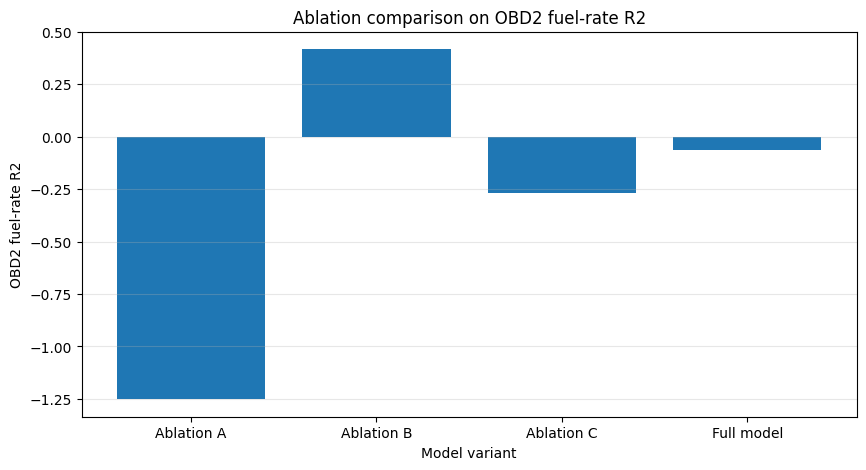

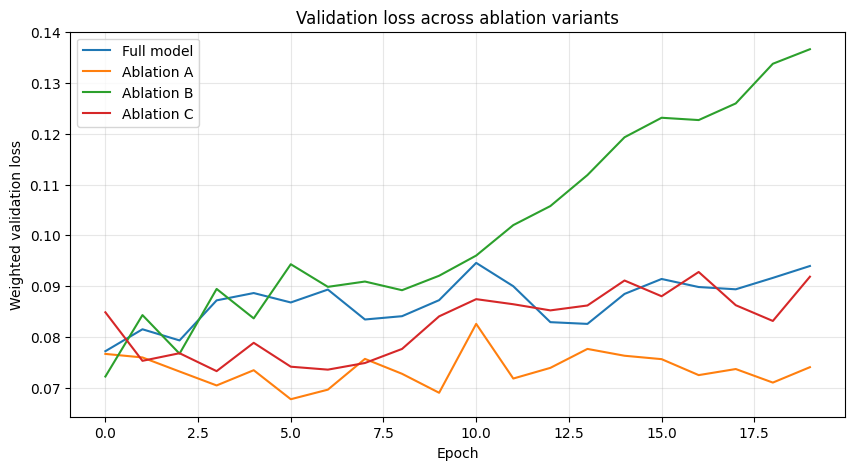

In [11]:
results_df = pd.DataFrame(results_rows).sort_values('variant_name').reset_index(drop=True)
results_csv_path = os.path.join(OUTPUT_DIR, 'ablation_results_summary.csv')
results_df.to_csv(results_csv_path, index=False)

with open(os.path.join(OUTPUT_DIR, 'ablation_feature_names.json'), 'w') as fh:
    json.dump(feature_cols, fh, indent=2)

print('Saved ablation summary to:', results_csv_path)
display(results_df)

plt.figure(figsize=(10, 5))
plt.bar(results_df['variant_name'], results_df['obd2_fuel_r2'])
plt.title('Ablation comparison on OBD2 fuel-rate R2')
plt.xlabel('Model variant')
plt.ylabel('OBD2 fuel-rate R2')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
for variant_name, history in history_by_variant.items():
    plt.plot(history['val_total'], label=variant_name)
plt.title('Validation loss across ablation variants')
plt.xlabel('Epoch')
plt.ylabel('Weighted validation loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Add OBD2-only baselines

This section answers the natural target-domain question for the paper:

**what happens if we ignore transfer entirely and train only on the OBD2 diesel data?**

The baselines below use the same OBD2 train/validation/test split as the union-model and ablation experiments. That makes the comparison scientifically cleaner when we later discuss whether transfer learning adds value beyond a small target-only model.


OBD2-only baseline feature count: 9
OBD2-only baseline features: ['time_signal', 'latitude_deg', 'longitude_deg', 'vehicle_speed_kmh', 'load_percent', 'coolant_temp_c', 'manifold_pressure_kpa', 'trip_distance_miles', 'trip_duration_min']
OBD2 train/val/test rows: 2275 569 780
OBD2-only mean predictor: MSE=0.9110 RMSE=0.9545 MAE=0.7029 R2=-0.0380
OBD2-only linear regression: MSE=2.7329 RMSE=1.6531 MAE=1.3548 R2=-2.1139
OBD2-only random forest: MSE=0.0946 RMSE=0.3075 MAE=0.1761 R2=0.8922
Early stopping OBD2-only MLP at epoch 32
OBD2-only neural network: MSE=1.3255 RMSE=1.1513 MAE=0.7262 R2=-0.5103

Saved OBD2-only baseline summary to: /content/drive/MyDrive/Data/VED-dataset/leakage_controlled_outputs/obd2_only_baseline_results.csv


,model_name,train_domain,feature_setting,rmse,mae,r2
0,OBD2-only random forest,OBD2 only,9 OBD2-only features (leakage-controlled),0.307518,0.176141,0.892248
1,OBD2-only mean predictor,OBD2 only,9 OBD2-only features (leakage-controlled),0.954481,0.702905,-0.038047
2,OBD2-only neural network,OBD2 only,9 OBD2-only features (leakage-controlled),1.151322,0.726158,-0.510344
3,OBD2-only linear regression,OBD2 only,9 OBD2-only features (leakage-controlled),1.653136,1.354779,-2.113867


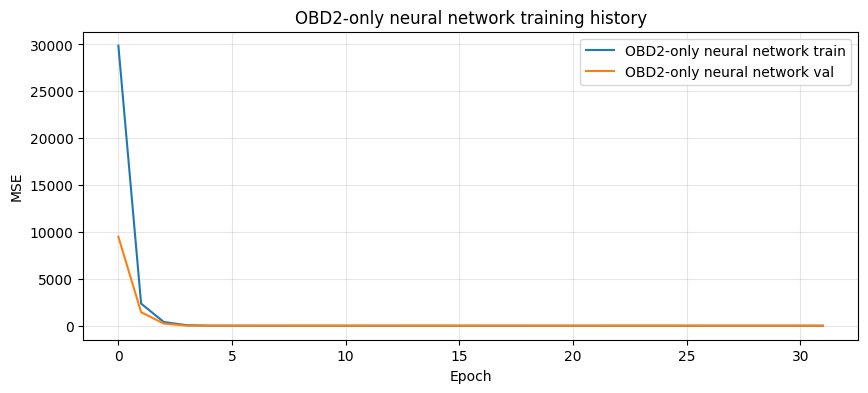

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

obd2_feature_names = [name for name in feature_cols if name in shared or name in obd2_only]
obd2_feature_idx = [feature_cols.index(name) for name in obd2_feature_names]

X_obd2_train_baseline = X_obd2_train_scaled[:, obd2_feature_idx]
X_obd2_val_baseline = X_obd2_val_scaled[:, obd2_feature_idx]
X_obd2_test_baseline = X_obd2_test_scaled[:, obd2_feature_idx]

y_obd2_train_fuel = y_obd2_train[:, 0].astype(float)
y_obd2_val_fuel = y_obd2_val[:, 0].astype(float)
y_obd2_test_fuel = y_obd2_test[:, 0].astype(float)

print('OBD2-only baseline feature count:', len(obd2_feature_names))
print('OBD2-only baseline features:', obd2_feature_names)
print('OBD2 train/val/test rows:', len(X_obd2_train_baseline), len(X_obd2_val_baseline), len(X_obd2_test_baseline))


def fuel_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'mse': float(mse),
        'rmse': float(math.sqrt(mse)),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


def print_fuel_metrics(label, metrics):
    print(
        f"{label}: MSE={metrics['mse']:.4f} RMSE={metrics['rmse']:.4f} "
        f"MAE={metrics['mae']:.4f} R2={metrics['r2']:.4f}"
    )


class OBD2OnlyFuelMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_obd2_only_mlp(x_train, y_train, x_val, y_val, epochs=250, lr=1e-3, batch_size=128, patience=25):
    model = OBD2OnlyFuelMLP(input_dim=x_train.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)

    best_state = None
    best_val = float('inf')
    wait = 0
    history = {'train_mse': [], 'val_mse': []}

    for epoch in range(epochs):
        model.train()
        running = 0.0
        seen = 0

        for bx, by in train_loader:
            bx = bx.to(device)
            by = by.to(device)

            optimizer.zero_grad()
            pred = model(bx)
            loss = criterion(pred, by)
            loss.backward()
            optimizer.step()

            running += loss.item() * len(bx)
            seen += len(bx)

        model.eval()
        with torch.no_grad():
            val_pred = model(x_val_t)
            val_loss = criterion(val_pred, y_val_t).item()

        train_loss = running / max(seen, 1)
        history['train_mse'].append(train_loss)
        history['val_mse'].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping OBD2-only MLP at epoch {epoch + 1}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


baseline_results = []

# Mean predictor
train_mean_fuel = float(np.mean(y_obd2_train_fuel))
mean_test_pred = np.full_like(y_obd2_test_fuel, train_mean_fuel, dtype=float)
mean_metrics = fuel_metrics(y_obd2_test_fuel, mean_test_pred)
print_fuel_metrics('OBD2-only mean predictor', mean_metrics)
baseline_results.append({
    'model_name': 'OBD2-only mean predictor',
    'train_domain': 'OBD2 only',
    'feature_setting': f'{len(obd2_feature_names)} OBD2-only features (leakage-controlled)',
    'rmse': mean_metrics['rmse'],
    'mae': mean_metrics['mae'],
    'r2': mean_metrics['r2'],
})

# Linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_obd2_train_baseline, y_obd2_train_fuel)
lin_test_pred = lin_reg.predict(X_obd2_test_baseline)
lin_metrics = fuel_metrics(y_obd2_test_fuel, lin_test_pred)
print_fuel_metrics('OBD2-only linear regression', lin_metrics)
baseline_results.append({
    'model_name': 'OBD2-only linear regression',
    'train_domain': 'OBD2 only',
    'feature_setting': f'{len(obd2_feature_names)} OBD2-only features (leakage-controlled)',
    'rmse': lin_metrics['rmse'],
    'mae': lin_metrics['mae'],
    'r2': lin_metrics['r2'],
})

# Random forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_obd2_train_baseline, y_obd2_train_fuel)
rf_test_pred = rf.predict(X_obd2_test_baseline)
rf_metrics = fuel_metrics(y_obd2_test_fuel, rf_test_pred)
print_fuel_metrics('OBD2-only random forest', rf_metrics)
baseline_results.append({
    'model_name': 'OBD2-only random forest',
    'train_domain': 'OBD2 only',
    'feature_setting': f'{len(obd2_feature_names)} OBD2-only features (leakage-controlled)',
    'rmse': rf_metrics['rmse'],
    'mae': rf_metrics['mae'],
    'r2': rf_metrics['r2'],
})

# OBD2-only neural network
obd2_only_mlp, obd2_only_mlp_history = train_obd2_only_mlp(
    X_obd2_train_baseline,
    y_obd2_train_fuel,
    X_obd2_val_baseline,
    y_obd2_val_fuel,
)
obd2_only_mlp.eval()
with torch.no_grad():
    mlp_test_pred = obd2_only_mlp(torch.tensor(X_obd2_test_baseline, dtype=torch.float32).to(device)).cpu().numpy()
mlp_metrics = fuel_metrics(y_obd2_test_fuel, mlp_test_pred)
print_fuel_metrics('OBD2-only neural network', mlp_metrics)
baseline_results.append({
    'model_name': 'OBD2-only neural network',
    'train_domain': 'OBD2 only',
    'feature_setting': f'{len(obd2_feature_names)} OBD2-only features (leakage-controlled)',
    'rmse': mlp_metrics['rmse'],
    'mae': mlp_metrics['mae'],
    'r2': mlp_metrics['r2'],
})

baseline_results_df = pd.DataFrame(baseline_results).sort_values('r2', ascending=False).reset_index(drop=True)
baseline_results_path = os.path.join(OUTPUT_DIR, 'obd2_only_baseline_results.csv')
baseline_results_df.to_csv(baseline_results_path, index=False)

print('\nSaved OBD2-only baseline summary to:', baseline_results_path)
display(baseline_results_df)

plt.figure(figsize=(10, 4))
plt.plot(obd2_only_mlp_history['train_mse'], label='OBD2-only neural network train')
plt.plot(obd2_only_mlp_history['val_mse'], label='OBD2-only neural network val')
plt.title('OBD2-only neural network training history')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Build a paper-facing comparison table

This final block puts the new OBD2-only baselines beside the cross-domain models already used in the paper.

Important note for the document:
- use the **Full model** row from this notebook as the authoritative union-model result when discussing the ablation study,
- and treat **Ablation B** as the strongest supported model in the current evidence.

That avoids mixing the earlier standalone union-notebook number with the newer ablation-pipeline number.


Saved phase-3 comparison table to: /content/drive/MyDrive/Data/VED-dataset/leakage_controlled_outputs/phase3_obd2_model_comparison.csv
Use the Full model and Ablation B rows from this notebook for the paper discussion so the comparison is internally consistent.


,model_name,train_domain,feature_setting,rmse,mae,r2
0,OBD2-only random forest,OBD2 only,9 OBD2-only features (leakage-controlled),0.307518,0.176141,8.922483e-01
1,Ablation B (mask + shared encoder),VED + labelled OBD2 train split,18 union features (leakage-controlled),0.715081,0.366944,4.173696e-01
2,Shared-feature transfer-learning MLP,VED + labelled OBD2 train split,3 shared features,0.920300,0.611100,3.500000e-02
3,OBD2-only mean predictor,OBD2 only,9 OBD2-only features (leakage-controlled),0.954481,0.702905,-3.804685e-02
4,Union full model (mask + domain-specific encod...,VED + labelled OBD2 train split,18 union features (leakage-controlled),0.965536,0.732115,-6.223358e-02
5,Ablation C (no mask + shared encoder),VED + labelled OBD2 train split,18 union features (leakage-controlled),1.054807,0.923354,-2.677357e-01
6,OBD2-only neural network,OBD2 only,9 OBD2-only features (leakage-controlled),1.151322,0.726158,-5.103445e-01
7,Ablation A (no mask + domain-specific encoders),VED + labelled OBD2 train split,18 union features (leakage-controlled),1.405839,1.344024,-1.251923e+00
8,OBD2-only linear regression,OBD2 only,9 OBD2-only features (leakage-controlled),1.653136,1.354779,-2.113867e+00
9,Deployment-like direct transfer,VED only,Saved VED feature set with source-mean fill,543.508100,543.507100,-2.817663e+05


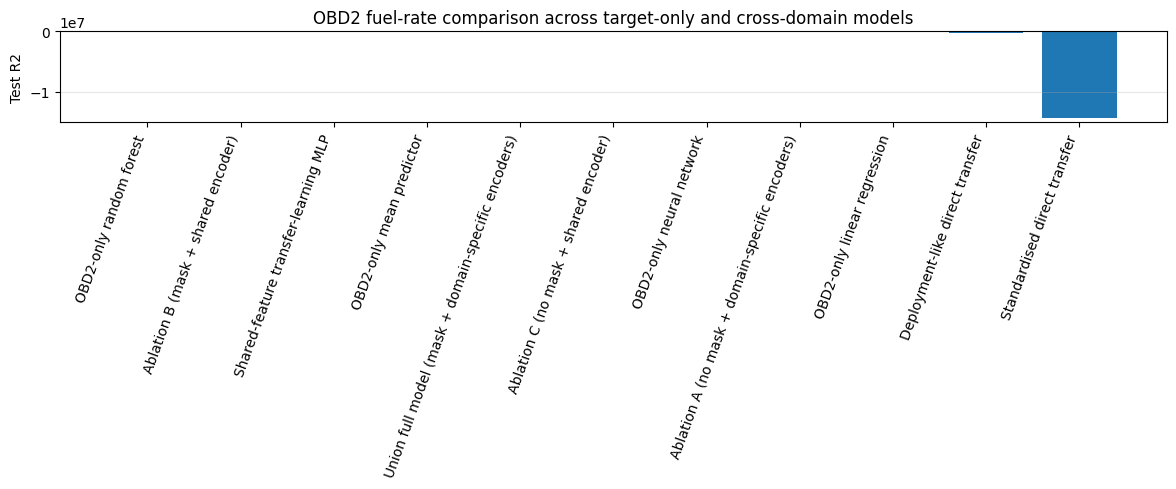


Models with negative R2 performed worse than predicting the OBD2 test-set mean.


,model_name,rmse,mae,r2
3,OBD2-only mean predictor,0.954481,0.702905,-3.804685e-02
4,Union full model (mask + domain-specific encod...,0.965536,0.732115,-6.223358e-02
5,Ablation C (no mask + shared encoder),1.054807,0.923354,-2.677357e-01
6,OBD2-only neural network,1.151322,0.726158,-5.103445e-01
7,Ablation A (no mask + domain-specific encoders),1.405839,1.344024,-1.251923e+00
8,OBD2-only linear regression,1.653136,1.354779,-2.113867e+00
9,Deployment-like direct transfer,543.508100,543.507100,-2.817663e+05
10,Standardised direct transfer,3554.257300,3554.257100,-1.439396e+07


In this study that mainly indicates failed transfer or failed feature usage: the model is producing predictions that are systematically mis-scaled, nearly constant, or otherwise misaligned with the held-out diesel fuel-rate signal.


In [13]:
# Reference rows from earlier notebooks, kept here so the paper comparison can be viewed in one place.
# If those notebooks are rerun later, update these constants.
reference_rows = [
    {
        'model_name': 'Deployment-like direct transfer',
        'train_domain': 'VED only',
        'feature_setting': 'Saved VED feature set with source-mean fill',
        'rmse': 543.5081,
        'mae': 543.5071,
        'r2': -281766.2850,
    },
    {
        'model_name': 'Standardised direct transfer',
        'train_domain': 'VED only',
        'feature_setting': 'Shared-feature preprocessing before adaptation',
        'rmse': 3554.2573,
        'mae': 3554.2571,
        'r2': -14393963.4402,
    },
    {
        'model_name': 'Shared-feature transfer-learning MLP',
        'train_domain': 'VED + labelled OBD2 train split',
        'feature_setting': '3 shared features',
        'rmse': 0.9203,
        'mae': 0.6111,
        'r2': 0.0350,
    },
]

variant_name_map = {
    'Full model': 'Union full model (mask + domain-specific encoders)',
    'Ablation A': 'Ablation A (no mask + domain-specific encoders)',
    'Ablation B': 'Ablation B (mask + shared encoder)',
    'Ablation C': 'Ablation C (no mask + shared encoder)',
}

cross_domain_rows = []
for _, row in results_df.iterrows():
    cross_domain_rows.append({
        'model_name': variant_name_map.get(row['variant_name'], row['paper_label']),
        'train_domain': 'VED + labelled OBD2 train split',
        'feature_setting': f'{len(feature_cols)} union features (leakage-controlled)',
        'rmse': float(row['obd2_fuel_rmse']),
        'mae': float(row['obd2_fuel_mae']),
        'r2': float(row['obd2_fuel_r2']),
    })

comparison_df = pd.concat(
    [
        pd.DataFrame(reference_rows),
        baseline_results_df,
        pd.DataFrame(cross_domain_rows),
    ],
    ignore_index=True,
).sort_values('r2', ascending=False).reset_index(drop=True)

comparison_path = os.path.join(OUTPUT_DIR, 'phase3_obd2_model_comparison.csv')
comparison_df.to_csv(comparison_path, index=False)

print('Saved phase-3 comparison table to:', comparison_path)
print('Use the Full model and Ablation B rows from this notebook for the paper discussion so the comparison is internally consistent.')
display(comparison_df)

plt.figure(figsize=(12, 5))
plt.bar(comparison_df['model_name'], comparison_df['r2'])
plt.xticks(rotation=70, ha='right')
plt.title('OBD2 fuel-rate comparison across target-only and cross-domain models')
plt.ylabel('Test R2')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

negative_r2_df = comparison_df[comparison_df['r2'] < 0].copy()
if len(negative_r2_df) > 0:
    print('\nModels with negative R2 performed worse than predicting the OBD2 test-set mean.')
    display(negative_r2_df[['model_name', 'rmse', 'mae', 'r2']])
    print(
        'In this study that mainly indicates failed transfer or failed feature usage: '
        'the model is producing predictions that are systematically mis-scaled, nearly constant, or otherwise misaligned '
        'with the held-out diesel fuel-rate signal.'
    )


Running multi-seed evaluation for seeds: [42, 43, 44, 45, 46]
Results will be saved under: /content/drive/MyDrive/Data/VED-dataset/leakage_controlled_outputs/multiseed_summary

[Union/Ablation models] seed=42
  Full model: OBD2 RMSE=0.9655, MAE=0.7321, R2=-0.0622
  Ablation A: OBD2 RMSE=1.4058, MAE=1.3440, R2=-1.2519
  Ablation B: OBD2 RMSE=0.7151, MAE=0.3669, R2=0.4174
  Ablation C: OBD2 RMSE=1.0548, MAE=0.9234, R2=-0.2677

[Union/Ablation models] seed=43
  Full model: OBD2 RMSE=0.8950, MAE=0.7486, R2=0.0872
  Ablation A: OBD2 RMSE=0.6190, MAE=0.3768, R2=0.5634
  Ablation B: OBD2 RMSE=0.8188, MAE=0.5668, R2=0.2360
  Ablation C: OBD2 RMSE=1.0062, MAE=0.8770, R2=-0.1536

[Union/Ablation models] seed=44
  Full model: OBD2 RMSE=0.9524, MAE=0.6963, R2=-0.0336
  Ablation A: OBD2 RMSE=0.9964, MAE=0.8983, R2=-0.1311
  Ablation B: OBD2 RMSE=0.9324, MAE=0.8281, R2=0.0093
  Ablation C: OBD2 RMSE=0.5830, MAE=0.4039, R2=0.6127

[Union/Ablation models] seed=45
  Full model: OBD2 RMSE=0.6742, MAE=0.

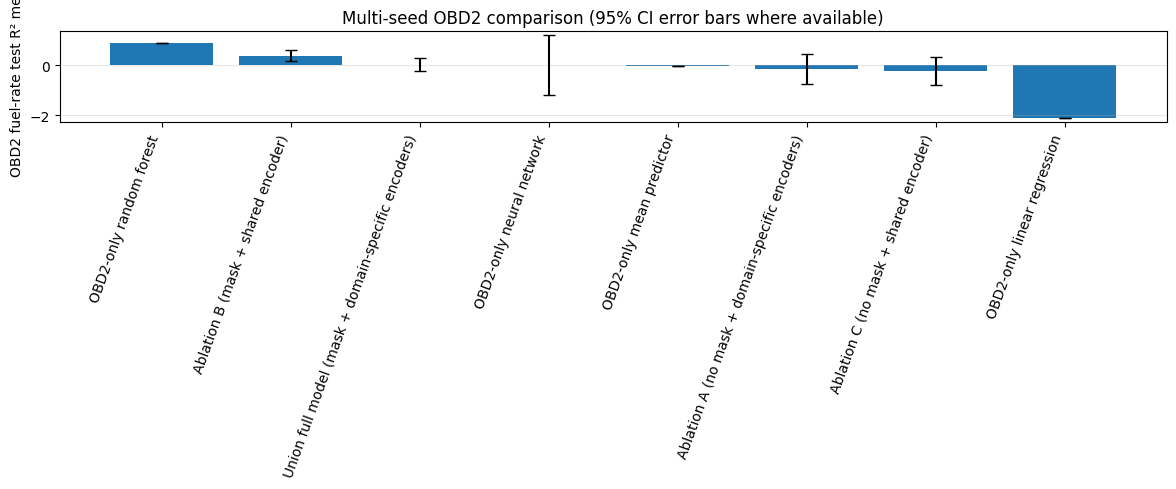


Notebook state restored to the original single-seed variables.
Important note:
- Full model, Ablation A/B/C, OBD2-only RF, and OBD2-only MLP now have multi-seed summaries.
- Direct transfer, standardised direct transfer, and shared-feature transfer MLP are still single-seed reference rows in this notebook.
- If needed, we can next add multi-seed reruns for those reference models too.


In [14]:
## Multi-seed evaluation for Phase 3 models
## This cell adds mean / SD / 95% CI results without changing earlier cells.

import io
import copy
import contextlib

MULTISEED_SEEDS = [42, 43, 44, 45, 46]
BASE_OUTPUT_DIR = OUTPUT_DIR
MULTISEED_OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, 'multiseed_summary')
os.makedirs(MULTISEED_OUTPUT_DIR, exist_ok=True)

print('Running multi-seed evaluation for seeds:', MULTISEED_SEEDS)
print('Results will be saved under:', MULTISEED_OUTPUT_DIR)


def set_all_seeds(seed):
    global SEED
    SEED = int(seed)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass


def summarize_values(values):
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = float(np.mean(values))
    sd = float(np.std(values, ddof=1)) if n > 1 else 0.0
    ci95 = float(1.96 * sd / np.sqrt(n)) if n > 1 else 0.0
    return mean, sd, ci95


def add_summary_stats(summary_row, prefix, values):
    mean, sd, ci95 = summarize_values(values)
    summary_row[f'{prefix}_mean'] = mean
    summary_row[f'{prefix}_sd'] = sd
    summary_row[f'{prefix}_ci95'] = ci95


def make_single_run_summary(df, model_name_col='model_name'):
    rows = []
    for _, row in df.iterrows():
        out = {
            'model_name': row[model_name_col],
            'n_runs': 1,
            'estimate_type': 'single_run_or_deterministic',
        }
        add_summary_stats(out, 'rmse', [row['rmse']])
        add_summary_stats(out, 'mae', [row['mae']])
        add_summary_stats(out, 'r2', [row['r2']])
        rows.append(out)
    return pd.DataFrame(rows)


# ------------------------------------------------------------------
# Preserve notebook state so the earlier single-seed outputs stay intact
# ------------------------------------------------------------------
original_seed = SEED
original_output_dir = OUTPUT_DIR
original_results_rows = copy.deepcopy(results_rows)
original_history_by_variant = copy.deepcopy(history_by_variant)
original_predictions_by_variant = copy.deepcopy(predictions_by_variant)
original_display = globals().get('display', None)

# ------------------------------------------------------------------
# 1) Multi-seed union / ablation runs
# ------------------------------------------------------------------
variant_configs = [
    ('Full model', 'Union features + mask + domain-specific encoders', True, True),
    ('Ablation A', 'Union features + no mask + domain-specific encoders', False, True),
    ('Ablation B', 'Union features + mask + shared encoder only', True, False),
    ('Ablation C', 'Union features + no mask + shared encoder only', False, False),
]

variant_run_rows = []

for seed in MULTISEED_SEEDS:
    print(f'\n[Union/Ablation models] seed={seed}')
    set_all_seeds(seed)

    seed_output_dir = os.path.join(BASE_OUTPUT_DIR, 'multiseed_runs', f'seed_{seed}')
    os.makedirs(seed_output_dir, exist_ok=True)
    OUTPUT_DIR = seed_output_dir

    # avoid dataframe display spam from run_variant(...)
    globals()['display'] = lambda *args, **kwargs: None

    for variant_name, paper_label, use_mask, use_domain_specific_encoders in variant_configs:
        with contextlib.redirect_stdout(io.StringIO()):
            model, history, ved_pred, obd2_pred, _ = run_variant(
                variant_name=variant_name,
                paper_label=paper_label,
                use_mask=use_mask,
                use_domain_specific_encoders=use_domain_specific_encoders,
            )

        row = next(item for item in results_rows if item['variant_name'] == variant_name)
        row = copy.deepcopy(row)
        row['seed'] = seed
        row['model_name'] = variant_name_map.get(variant_name, row['paper_label'])
        variant_run_rows.append(row)

        print(
            f"  {variant_name}: "
            f"OBD2 RMSE={row['obd2_fuel_rmse']:.4f}, "
            f"MAE={row['obd2_fuel_mae']:.4f}, "
            f"R2={row['obd2_fuel_r2']:.4f}"
        )

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# restore display
if original_display is not None:
    globals()['display'] = original_display

variant_runs_df = pd.DataFrame(variant_run_rows)
variant_runs_path = os.path.join(MULTISEED_OUTPUT_DIR, 'multiseed_union_ablation_runs.csv')
variant_runs_df.to_csv(variant_runs_path, index=False)

variant_summary_rows = []
for variant_name, group in variant_runs_df.groupby('variant_name', sort=False):
    first = group.iloc[0]
    summary = {
        'variant_name': variant_name,
        'model_name': first['model_name'],
        'paper_label': first['paper_label'],
        'uses_mask': bool(first['uses_mask']),
        'uses_domain_specific_encoders': bool(first['uses_domain_specific_encoders']),
        'n_runs': len(group),
        'estimate_type': 'multi_seed',
    }

    for metric_col in [
        'ved_fuel_rmse', 'ved_fuel_mae', 'ved_fuel_r2',
        'ved_soc_rmse', 'ved_soc_mae', 'ved_soc_r2',
        'obd2_fuel_rmse', 'obd2_fuel_mae', 'obd2_fuel_r2',
    ]:
        add_summary_stats(summary, metric_col, group[metric_col].values)

    variant_summary_rows.append(summary)

variant_summary_df = pd.DataFrame(variant_summary_rows).sort_values('obd2_fuel_r2_mean', ascending=False).reset_index(drop=True)
variant_summary_path = os.path.join(MULTISEED_OUTPUT_DIR, 'multiseed_union_ablation_summary.csv')
variant_summary_df.to_csv(variant_summary_path, index=False)

print('\nSaved union/ablation multi-seed runs to:', variant_runs_path)
print('Saved union/ablation multi-seed summary to:', variant_summary_path)
display(
    variant_summary_df[
        [
            'model_name', 'n_runs',
            'obd2_fuel_rmse_mean', 'obd2_fuel_rmse_sd', 'obd2_fuel_rmse_ci95',
            'obd2_fuel_mae_mean', 'obd2_fuel_mae_sd', 'obd2_fuel_mae_ci95',
            'obd2_fuel_r2_mean', 'obd2_fuel_r2_sd', 'obd2_fuel_r2_ci95',
        ]
    ]
)

# ------------------------------------------------------------------
# 2) Multi-seed OBD2-only baselines that actually depend on randomness
# ------------------------------------------------------------------
baseline_run_rows = []

# deterministic baselines: mean predictor + linear regression
deterministic_baselines_df = baseline_results_df[
    baseline_results_df['model_name'].isin(
        ['OBD2-only mean predictor', 'OBD2-only linear regression']
    )
].copy()

for _, row in deterministic_baselines_df.iterrows():
    baseline_run_rows.append({
        'seed': np.nan,
        'model_name': row['model_name'],
        'train_domain': row['train_domain'],
        'feature_setting': row['feature_setting'],
        'rmse': float(row['rmse']),
        'mae': float(row['mae']),
        'r2': float(row['r2']),
        'estimate_type': 'deterministic_single_split',
    })

# random forest + OBD2-only MLP
for seed in MULTISEED_SEEDS:
    print(f'\n[OBD2-only baselines] seed={seed}')
    set_all_seeds(seed)

    # Random forest
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=seed,
        n_jobs=-1,
    )
    rf.fit(X_obd2_train_baseline, y_obd2_train_fuel)
    rf_test_pred = rf.predict(X_obd2_test_baseline)
    rf_metrics = fuel_metrics(y_obd2_test_fuel, rf_test_pred)
    print(
        f"  RF: RMSE={rf_metrics['rmse']:.4f}, "
        f"MAE={rf_metrics['mae']:.4f}, "
        f"R2={rf_metrics['r2']:.4f}"
    )
    baseline_run_rows.append({
        'seed': seed,
        'model_name': 'OBD2-only random forest',
        'train_domain': 'OBD2 only',
        'feature_setting': f'{len(obd2_feature_names)} OBD2-only features (leakage-controlled)',
        'rmse': rf_metrics['rmse'],
        'mae': rf_metrics['mae'],
        'r2': rf_metrics['r2'],
        'estimate_type': 'multi_seed',
    })

    # OBD2-only MLP
    with contextlib.redirect_stdout(io.StringIO()):
        obd2_only_mlp, _ = train_obd2_only_mlp(
            X_obd2_train_baseline,
            y_obd2_train_fuel,
            X_obd2_val_baseline,
            y_obd2_val_fuel,
        )

    obd2_only_mlp.eval()
    with torch.no_grad():
        mlp_test_pred = obd2_only_mlp(
            torch.tensor(X_obd2_test_baseline, dtype=torch.float32).to(device)
        ).cpu().numpy()

    mlp_metrics = fuel_metrics(y_obd2_test_fuel, mlp_test_pred)
    print(
        f"  OBD2-only MLP: RMSE={mlp_metrics['rmse']:.4f}, "
        f"MAE={mlp_metrics['mae']:.4f}, "
        f"R2={mlp_metrics['r2']:.4f}"
    )
    baseline_run_rows.append({
        'seed': seed,
        'model_name': 'OBD2-only neural network',
        'train_domain': 'OBD2 only',
        'feature_setting': f'{len(obd2_feature_names)} OBD2-only features (leakage-controlled)',
        'rmse': mlp_metrics['rmse'],
        'mae': mlp_metrics['mae'],
        'r2': mlp_metrics['r2'],
        'estimate_type': 'multi_seed',
    })

    del rf, obd2_only_mlp
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

baseline_runs_df = pd.DataFrame(baseline_run_rows)
baseline_runs_path = os.path.join(MULTISEED_OUTPUT_DIR, 'multiseed_obd2_baseline_runs.csv')
baseline_runs_df.to_csv(baseline_runs_path, index=False)

baseline_summary_rows = []
for model_name, group in baseline_runs_df.groupby('model_name', sort=False):
    first = group.iloc[0]
    summary = {
        'model_name': model_name,
        'train_domain': first['train_domain'],
        'feature_setting': first['feature_setting'],
        'n_runs': int(group['seed'].notna().sum()) if first['estimate_type'] == 'multi_seed' else 1,
        'estimate_type': first['estimate_type'],
    }
    add_summary_stats(summary, 'rmse', group['rmse'].values)
    add_summary_stats(summary, 'mae', group['mae'].values)
    add_summary_stats(summary, 'r2', group['r2'].values)
    baseline_summary_rows.append(summary)

baseline_summary_df = pd.DataFrame(baseline_summary_rows).sort_values('r2_mean', ascending=False).reset_index(drop=True)
baseline_summary_path = os.path.join(MULTISEED_OUTPUT_DIR, 'multiseed_obd2_baseline_summary.csv')
baseline_summary_df.to_csv(baseline_summary_path, index=False)

print('\nSaved OBD2 baseline multi-seed runs to:', baseline_runs_path)
print('Saved OBD2 baseline multi-seed summary to:', baseline_summary_path)
display(baseline_summary_df)

# ------------------------------------------------------------------
# 3) Paper-facing combined summary
# ------------------------------------------------------------------
transfer_summary_for_table3 = variant_summary_df[
    ['model_name', 'n_runs', 'estimate_type', 'obd2_fuel_rmse_mean', 'obd2_fuel_rmse_sd', 'obd2_fuel_rmse_ci95',
     'obd2_fuel_mae_mean', 'obd2_fuel_mae_sd', 'obd2_fuel_mae_ci95',
     'obd2_fuel_r2_mean', 'obd2_fuel_r2_sd', 'obd2_fuel_r2_ci95']
].copy()

transfer_summary_for_table3 = transfer_summary_for_table3.rename(columns={
    'obd2_fuel_rmse_mean': 'rmse_mean',
    'obd2_fuel_rmse_sd': 'rmse_sd',
    'obd2_fuel_rmse_ci95': 'rmse_ci95',
    'obd2_fuel_mae_mean': 'mae_mean',
    'obd2_fuel_mae_sd': 'mae_sd',
    'obd2_fuel_mae_ci95': 'mae_ci95',
    'obd2_fuel_r2_mean': 'r2_mean',
    'obd2_fuel_r2_sd': 'r2_sd',
    'obd2_fuel_r2_ci95': 'r2_ci95',
})

baseline_summary_for_table3 = baseline_summary_df[
    ['model_name', 'n_runs', 'estimate_type', 'rmse_mean', 'rmse_sd', 'rmse_ci95', 'mae_mean', 'mae_sd', 'mae_ci95', 'r2_mean', 'r2_sd', 'r2_ci95']
].copy()

# keep current single-seed reference rows visible, but clearly flag them
single_seed_reference_df = pd.DataFrame(reference_rows).copy()
single_seed_reference_df['n_runs'] = 1
single_seed_reference_df['estimate_type'] = 'single_seed_reference'
single_seed_reference_df['rmse_mean'] = single_seed_reference_df['rmse']
single_seed_reference_df['rmse_sd'] = np.nan
single_seed_reference_df['rmse_ci95'] = np.nan
single_seed_reference_df['mae_mean'] = single_seed_reference_df['mae']
single_seed_reference_df['mae_sd'] = np.nan
single_seed_reference_df['mae_ci95'] = np.nan
single_seed_reference_df['r2_mean'] = single_seed_reference_df['r2']
single_seed_reference_df['r2_sd'] = np.nan
single_seed_reference_df['r2_ci95'] = np.nan
single_seed_reference_df = single_seed_reference_df[
    ['model_name', 'n_runs', 'estimate_type', 'rmse_mean', 'rmse_sd', 'rmse_ci95', 'mae_mean', 'mae_sd', 'mae_ci95', 'r2_mean', 'r2_sd', 'r2_ci95']
]

multiseed_comparison_df = pd.concat(
    [
        baseline_summary_for_table3,
        transfer_summary_for_table3,
        single_seed_reference_df,
    ],
    ignore_index=True,
).sort_values('r2_mean', ascending=False).reset_index(drop=True)

multiseed_comparison_path = os.path.join(MULTISEED_OUTPUT_DIR, 'multiseed_phase3_obd2_comparison.csv')
multiseed_comparison_df.to_csv(multiseed_comparison_path, index=False)

print('\nSaved combined Phase 3 multi-seed comparison to:', multiseed_comparison_path)
display(multiseed_comparison_df)

plt.figure(figsize=(12, 5))
plot_df = multiseed_comparison_df[multiseed_comparison_df['estimate_type'] != 'single_seed_reference'].copy()
plt.bar(plot_df['model_name'], plot_df['r2_mean'], yerr=plot_df['r2_ci95'].fillna(0.0), capsize=4)
plt.xticks(rotation=70, ha='right')
plt.ylabel('OBD2 fuel-rate test R² mean')
plt.title('Multi-seed OBD2 comparison (95% CI error bars where available)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4) Restore original notebook state
# ------------------------------------------------------------------
SEED = original_seed
OUTPUT_DIR = original_output_dir
results_rows = original_results_rows
history_by_variant = original_history_by_variant
predictions_by_variant = original_predictions_by_variant

if original_display is not None:
    globals()['display'] = original_display

print('\nNotebook state restored to the original single-seed variables.')
print('Important note:')
print('- Full model, Ablation A/B/C, OBD2-only RF, and OBD2-only MLP now have multi-seed summaries.')
print('- Direct transfer, standardised direct transfer, and shared-feature transfer MLP are still single-seed reference rows in this notebook.')
print('- If needed, we can next add multi-seed reruns for those reference models too.')